In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import calendar

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


### Preliminary data analysis

In [125]:
prefix = "D:/IITK Certification/Capstone/Capstone 3/"
items = pd.read_csv(prefix +'items.csv')
restaurants = pd.read_csv(prefix +'resturants.csv')
sales = pd.read_csv(prefix +'sales.csv')

In [126]:
items.head()

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [127]:
restaurants.head()

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


In [128]:
sales.head()

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


In [129]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    str    
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 4.0 KB


In [130]:
restaurants.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      6 non-null      int64
 1   name    6 non-null      str  
dtypes: int64(1), str(1)
memory usage: 228.0 bytes


In [131]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  str    
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 3.3 MB


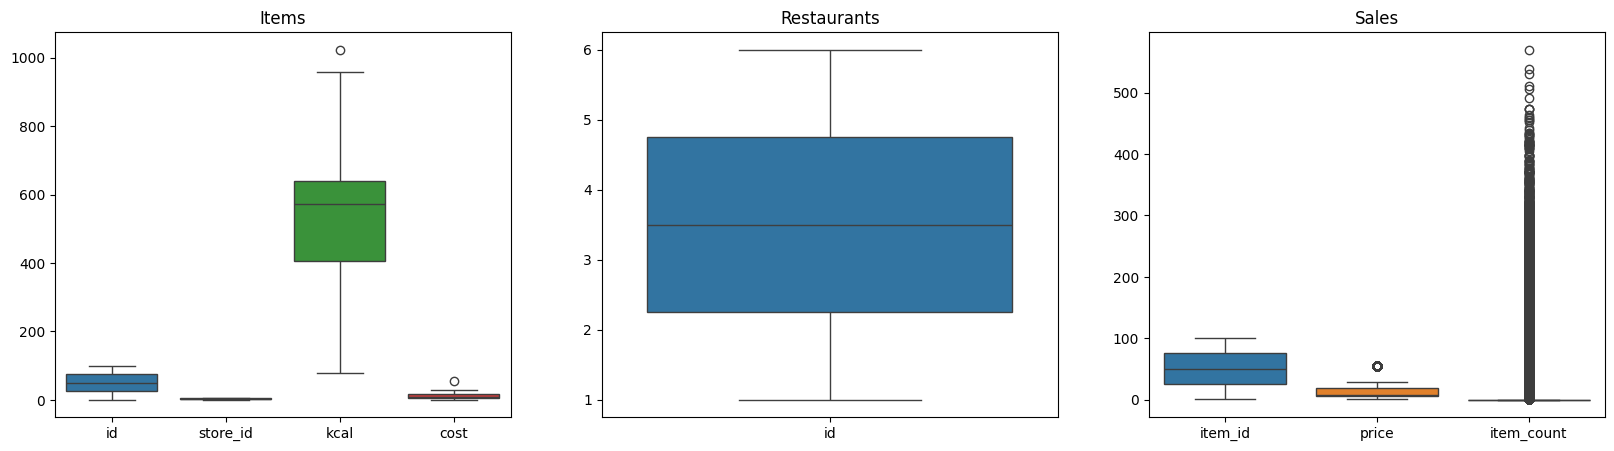

In [132]:
### Checking outliers in each dataset via box plots
### Select only numerical fields
items_num = items.select_dtypes(include=np.number)
restaurants_num = restaurants.select_dtypes(include=np.number)
sales_num = sales.select_dtypes(include=np.number)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.boxplot(data=items_num, ax=axes[0])
sns.boxplot(data=restaurants_num, ax=axes[1])
sns.boxplot(data=sales_num, ax=axes[2])
axes[0].set_title('Items')
axes[1].set_title('Restaurants')
axes[2].set_title('Sales')
plt.show()



In [133]:
### Only items count fields in Sales dataset seem to have outliers with teh dataset having a long right tail.

In [134]:
### Merging all 3 datsets together
merged_data = pd.merge(sales, items, left_on = "item_id", right_on = "id", how = "left")
data = pd.merge(merged_data, restaurants, left_on = 'store_id', right_on = 'id')

data.rename(columns = {"name_x" : "item_name", "name_y": "restaurant_name"}, inplace = True)
data.drop(columns = ['id_x', 'id_y', 'cost'], inplace = True)
data.head()

,date,item_id,price,item_count,store_id,item_name,kcal,restaurant_name
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,Bob's Diner
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,Bob's Diner
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,Bob's Diner
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,Bob's Diner
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,Bob's Diner


In [135]:
data.shape

(109600, 8)

In [136]:
# Check if the joining keys were duplicated in the original datasets
print("Unique item_id in sales:", sales['item_id'].nunique())
print("Unique id in items:", items['id'].nunique())
print("Unique store_id in sales:", items['store_id'].nunique())
print("Unique id in restaurants:", restaurants['id'].nunique())


Unique item_id in sales: 100
Unique id in items: 100
Unique store_id in sales: 6
Unique id in restaurants: 6


In [137]:
sales.shape, items.shape, restaurants.shape

((109600, 4), (100, 5), (6, 2))

### Exploratory Data Analysis (EDA)

In [138]:
sales.columns

Index(['date', 'item_id', 'price', 'item_count'], dtype='str')

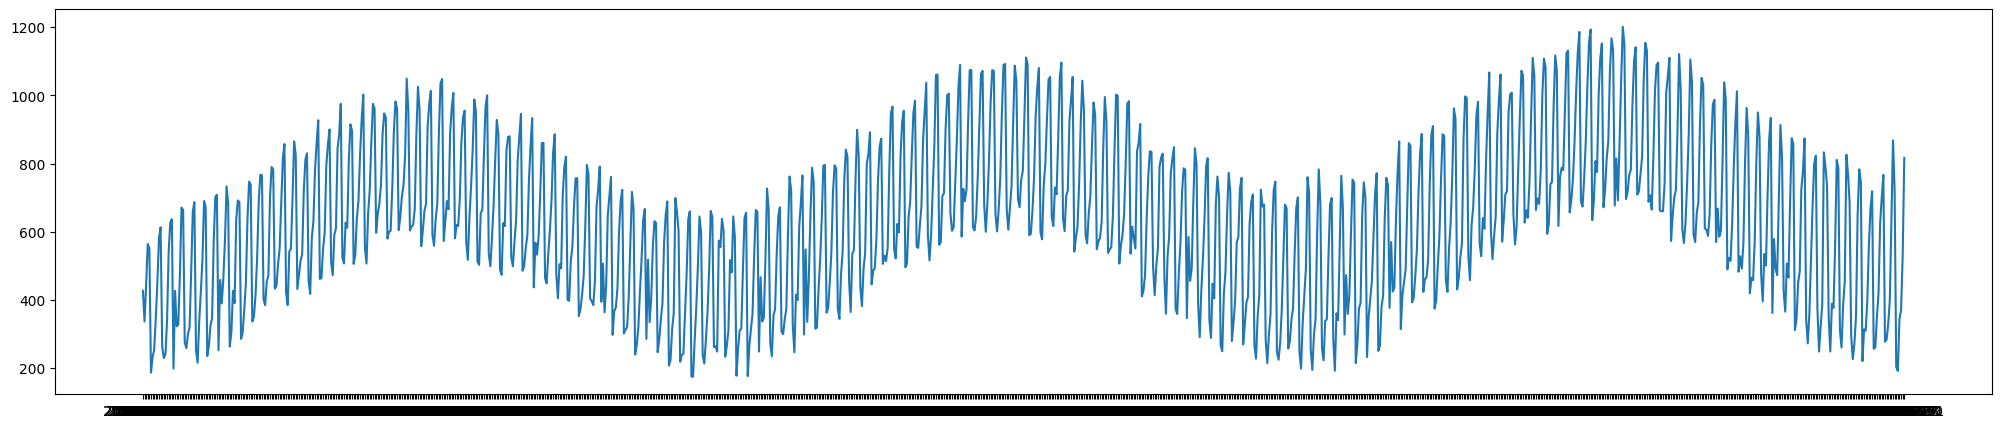

In [139]:
# Examine the overall sales to understand the pattern 

grpd = sales.groupby(['date'])[['item_count']].sum()
plt.figure(figsize = (25,5))
plt.plot(grpd)
plt.show()

In [140]:
### Average sales have gone up from 2019-21
### Not too much seasonal fluctuations in the sales data.
### Spikes are mostly even throughout the entire timeframe.

C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\3718199294.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette='viridis')


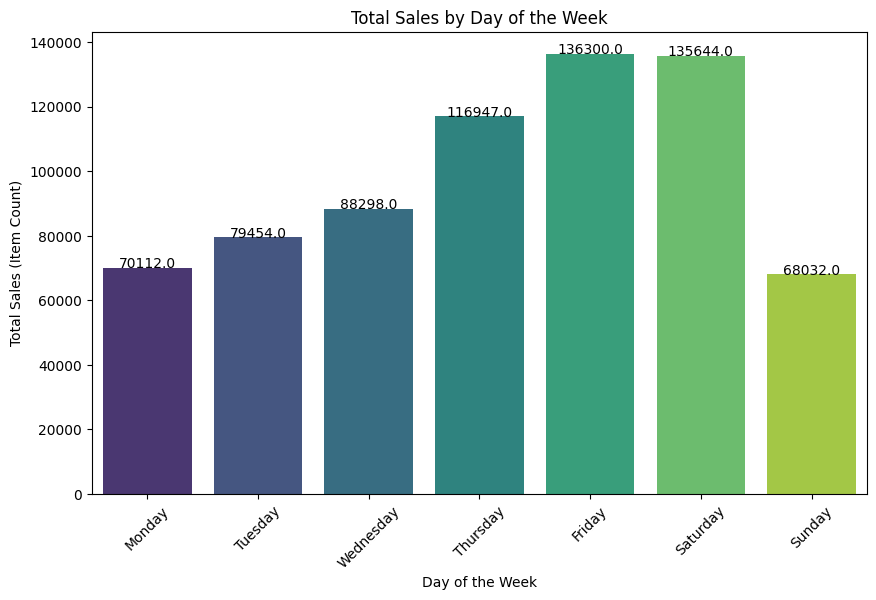

In [141]:
# Find out how sales fluctuate across different days of the week
# bar chart with days of the week on x-axis and average sales on y-axis
sales['date'] = pd.to_datetime(sales['date'])
sales['day_of_week'] = sales['date'].dt.day_name()
sales_by_day = sales.groupby('day_of_week')['item_count'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette='viridis')

for i, value in enumerate(sales_by_day.values):
    ax.text(
        i,
        value + 5,
        str(value),
        ha='center',
        fontsize=10
    )


plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales (Item Count)')
plt.xticks(rotation=45)
plt.show()


In [142]:
### Max sales happen on Fridays, followed by Saturdays.
### Sundays have least sales.


C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\3000386281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sales_by_month.index, y=sales_by_month.values, palette='Spectral')


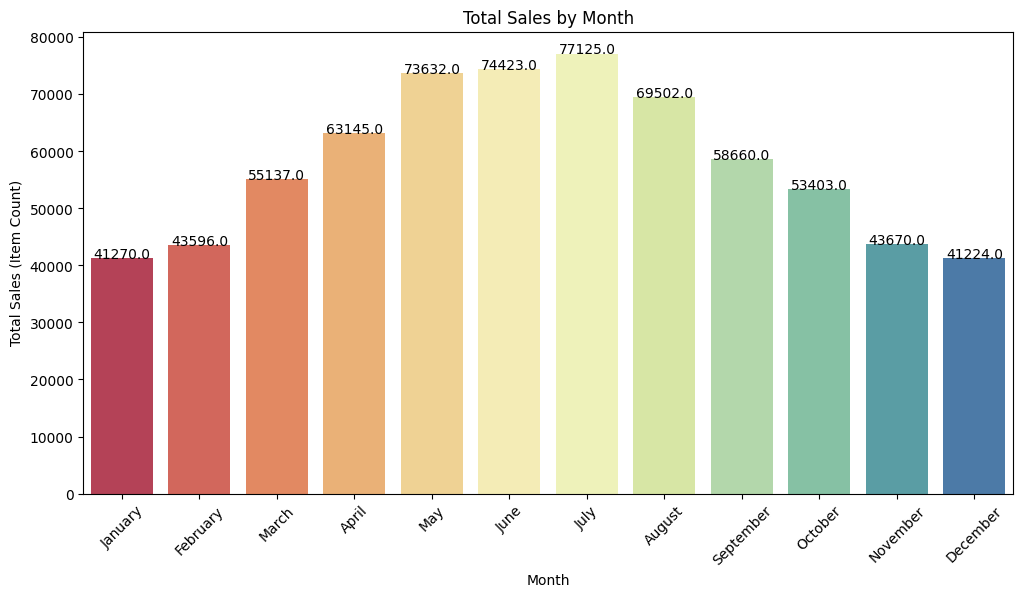

In [143]:
# Look for any noticeable trends in the sales data for different months of the year 
sales['month'] = sales['date'].dt.month_name()
sales_by_month = sales.groupby('month')['item_count'].sum().reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=sales_by_month.index, y=sales_by_month.values, palette='Spectral')
for i, value in enumerate(sales_by_month.values):
    ax.text(
        i,
        value + 5,
        str(value),
        ha='center',
        fontsize=10
    )
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales (Item Count)')
plt.xticks(rotation=45)
plt.show()


In [144]:
### July is the best month for sales while December is the worst month for sales.

C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\1076887944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sales_by_quarter.index.astype(str), y=sales_by_quarter.values, palette='Set2')


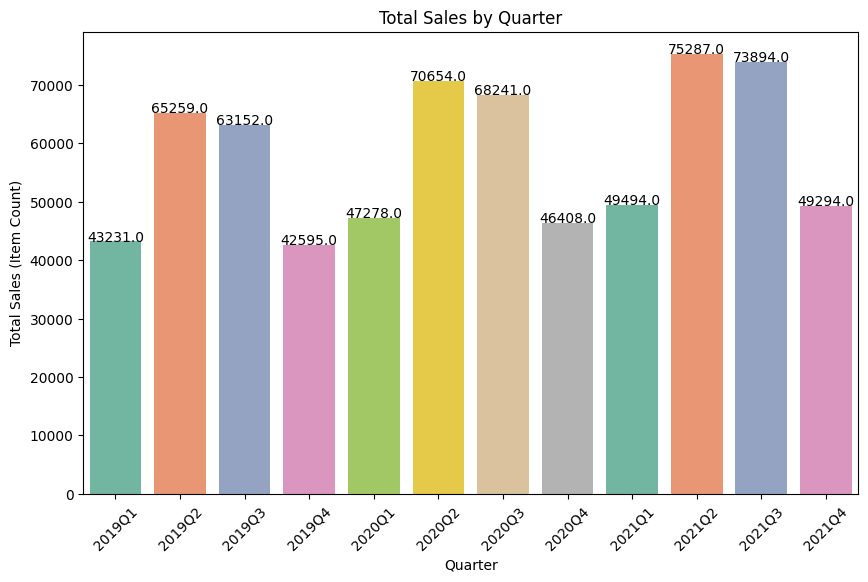

In [145]:
# Examine the sales distribution across different quarters averaged over the years. Identify any noticeable patterns.
sales['quarter'] = sales['date'].dt.to_period('Q')
sales_by_quarter = sales.groupby('quarter')['item_count'].sum()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=sales_by_quarter.index.astype(str), y=sales_by_quarter.values, palette='Set2')
for i, value in enumerate(sales_by_quarter.values):
    ax.text(
        i,
        value + 5,
        str(value),
        ha='center',
        fontsize=10
    )
plt.title('Total Sales by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Total Sales (Item Count)')
plt.xticks(rotation=45)
plt.show()


In [146]:
### Q2 is always the best quarter for sales, followed by Q3 
### Sales are least in Q4, followed by Q1.
### Howver, 2021 Q2 has shown significant growth compared to 2019 Q2.

In [147]:
# Compare the performances of the different restaurants. 
# Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days.

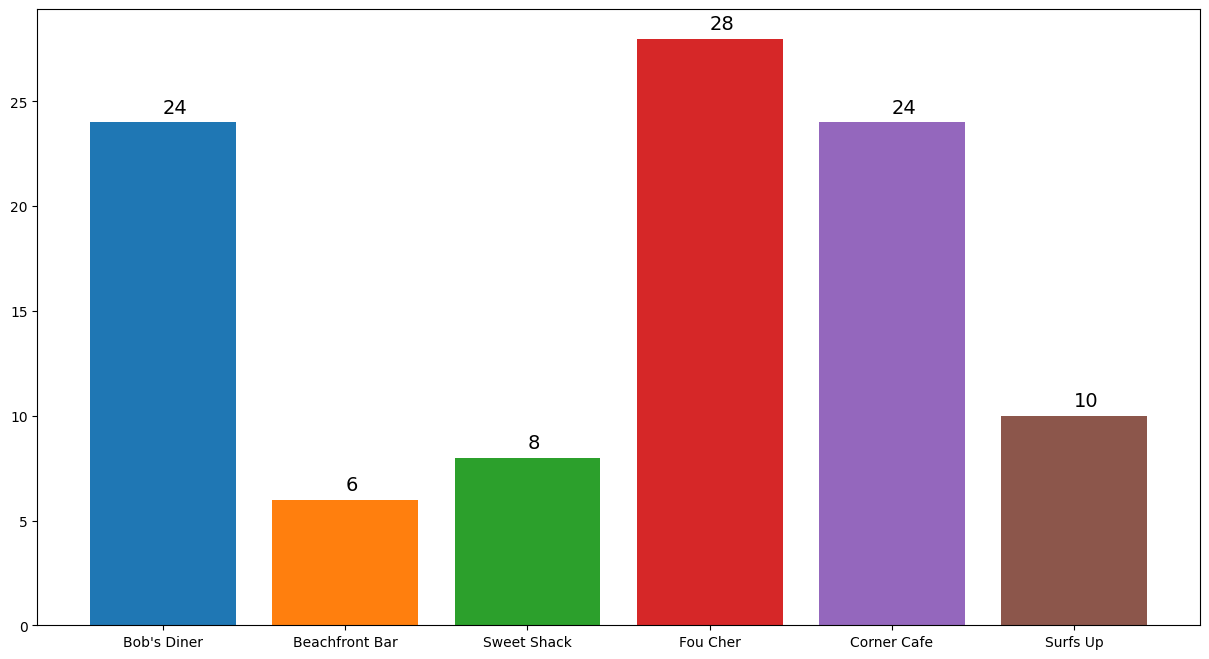

In [148]:
pal = sns.color_palette()
pal_list = list(pal)

items_served = items.groupby(['store_id']).agg({'id' : "nunique"}).squeeze()
plt.figure(figsize = (15,8))
plt.bar(items_served.index, items_served.values, color = pal)
plt.xticks(range(1,7), restaurants.name)
for i in range(1,7):
  plt.annotate(items_served[i], xy = (i, items_served[i]+0.45), size = 14)

plt.show()

In [203]:
### Fou Cher has the most number of items on the menu, followed by Bob's Diner and Corner Cafe.

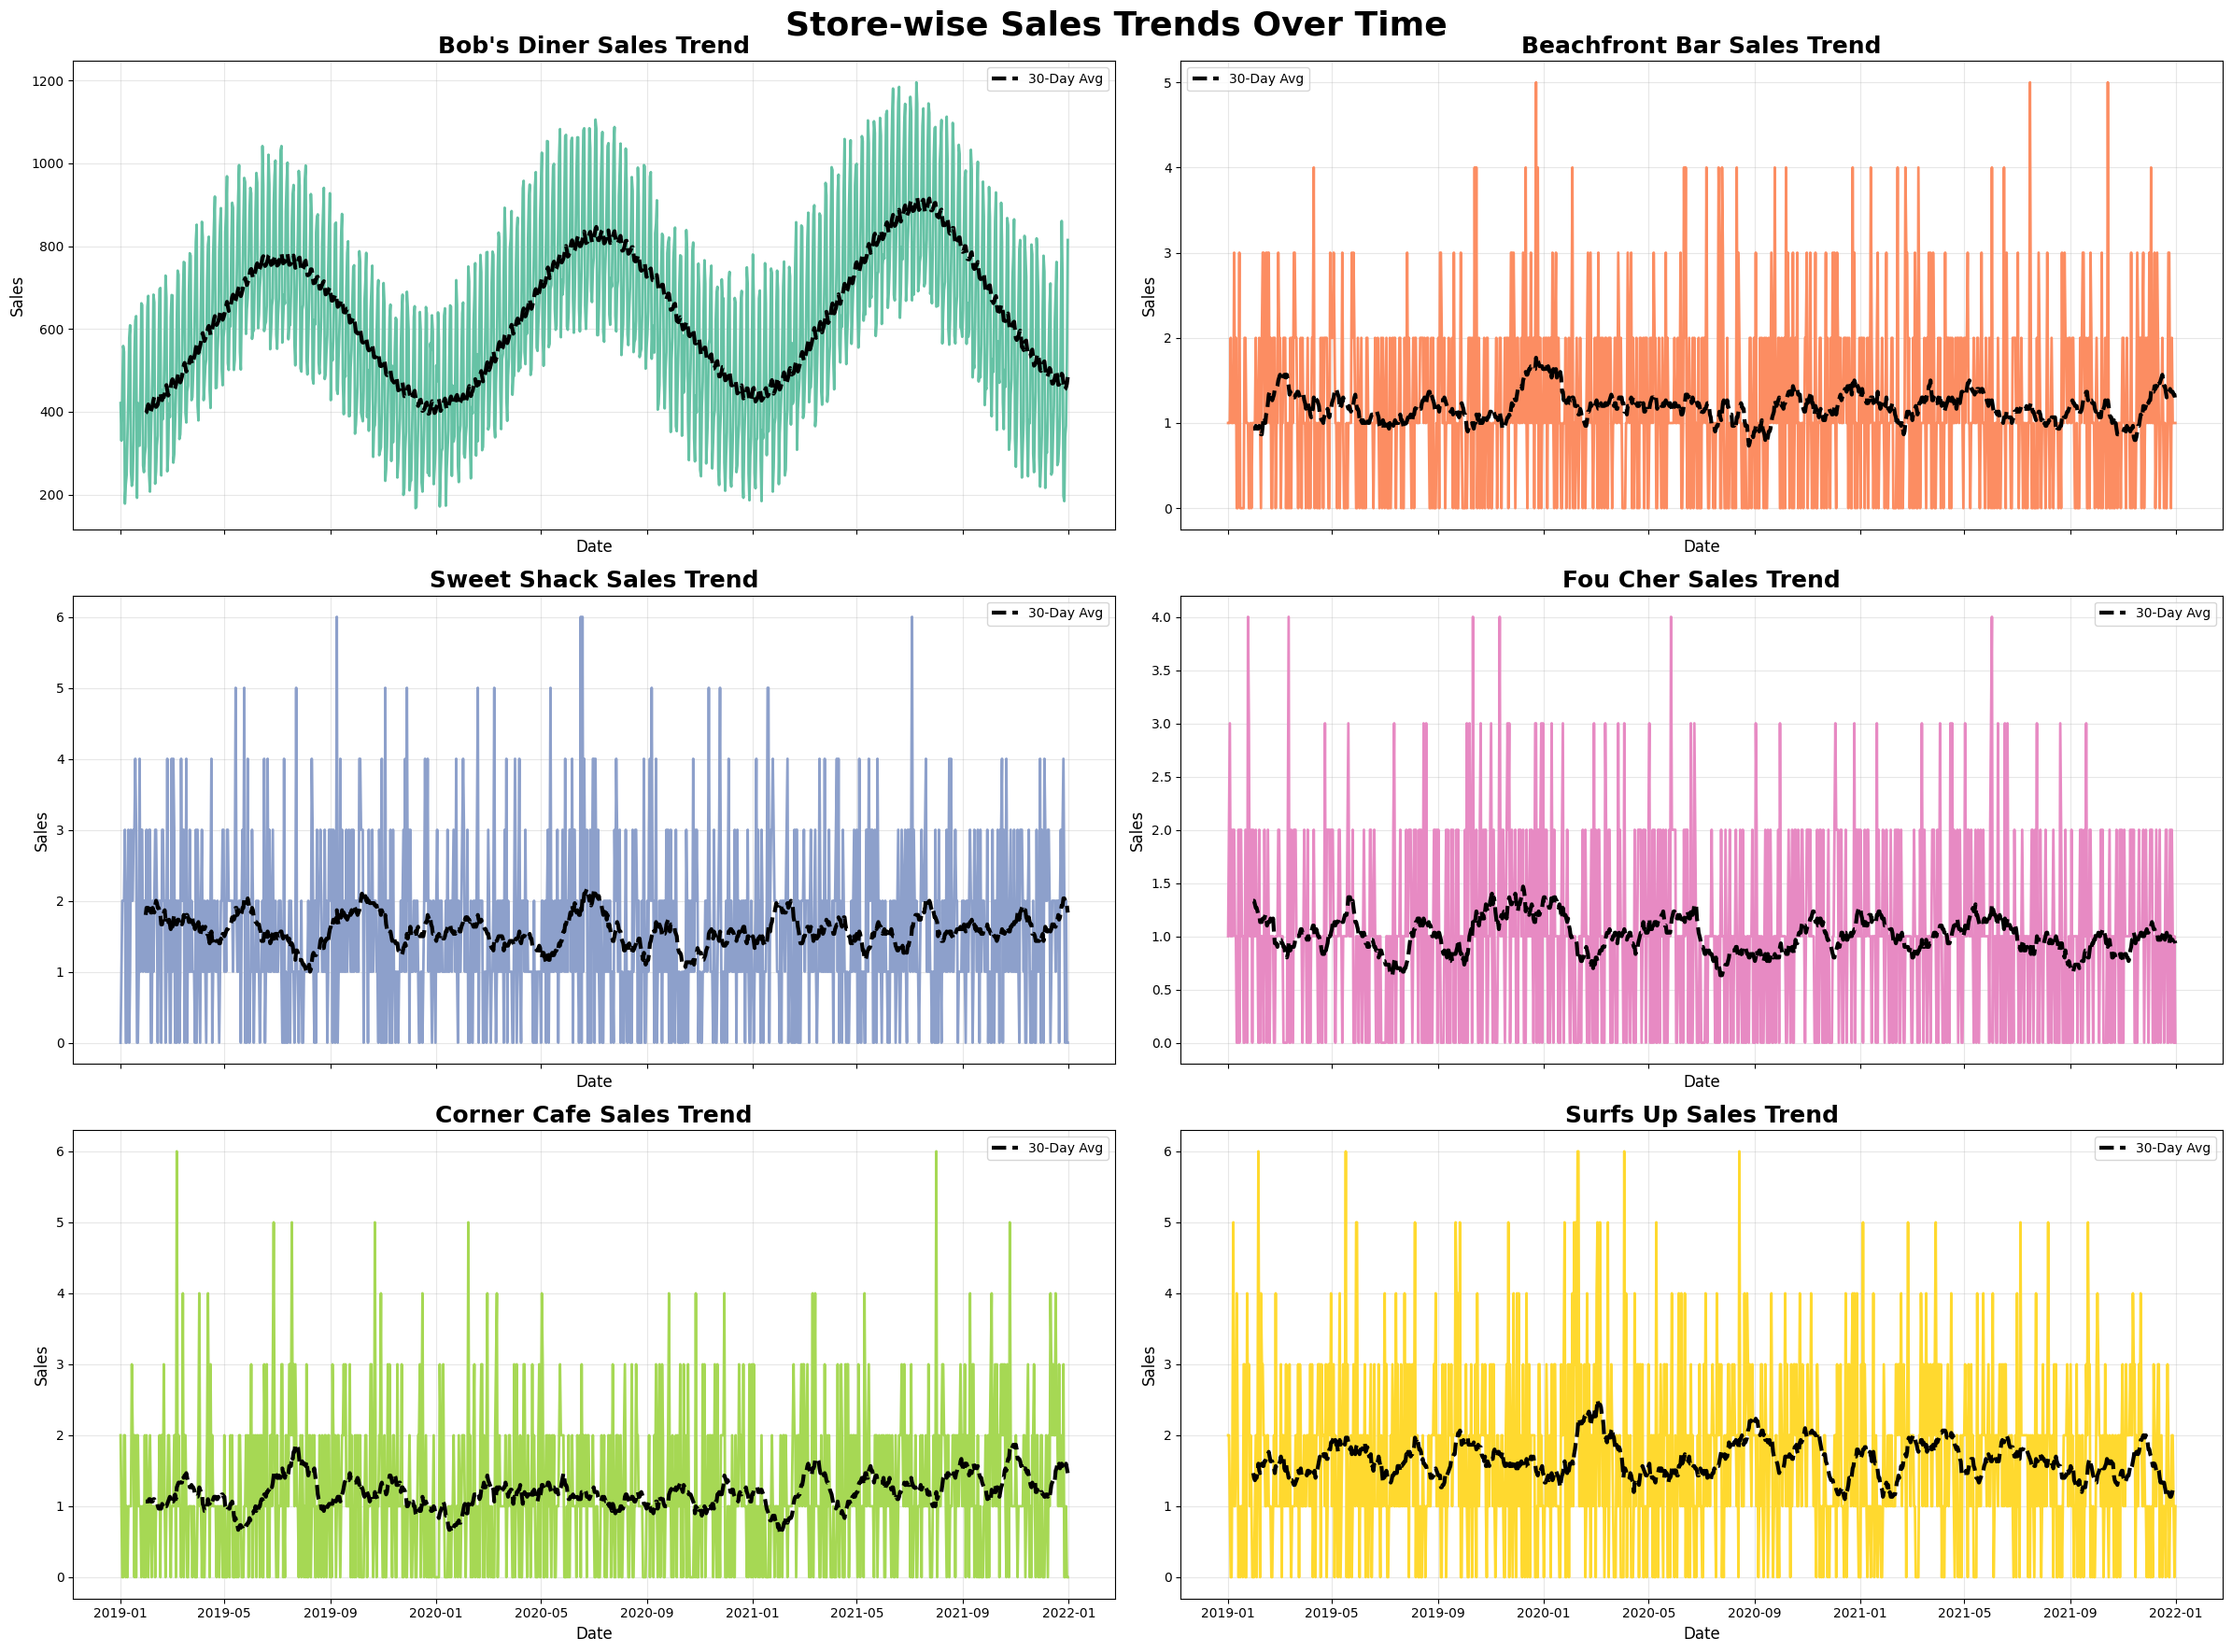

In [150]:
# Store-wise Sales Trend Analysis

# Convert date column
data['date'] = pd.to_datetime(data['date'])

# Create pivot table
plot_data = data.pivot_table(
    index='date',
    columns='store_id',
    values='item_count',
    aggfunc='sum'
)

# Sort by date
plot_data = plot_data.sort_index()

# Color palette
pal_list = sns.color_palette("Set2", 6)

# Create subplots
fig, ax = plt.subplots(
    3,
    2,
    figsize=(24,18),
    sharex=True
)

# Flatten axes for easier looping
ax = ax.flatten()

# Plot each store trend
for i in range(1, 7):

    # Plot line
    ax[i-1].plot(
        plot_data.index,
        plot_data[i],
        color=pal_list[i-1],
        linewidth=2
    )

    # Rolling average trend line
    ax[i-1].plot(
        plot_data[i].rolling(30).mean(),
        color='black',
        linewidth=3,
        linestyle='--',
        label='30-Day Avg'
    )

    # Store title
    store_name = restaurants.loc[
        restaurants.id == i,
        'name'
    ].values[0]

    ax[i-1].set_title(
        f'{store_name} Sales Trend',
        fontsize=18,
        fontweight='bold'
    )

    # Labels
    ax[i-1].set_xlabel('Date', fontsize=12)
    ax[i-1].set_ylabel('Sales', fontsize=12)

    # Grid
    ax[i-1].grid(alpha=0.3)

    # Legend
    ax[i-1].legend()

# Overall title
fig.suptitle(
    'Store-wise Sales Trends Over Time',
    fontsize=26,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
### Bob's Diner has massive sales compared to the other restaurants.
### While the others have less than 10 items sold, Bob's Diner trend revolves in the hundreds.
### Fou Cher has the lowest sales, with not even a single peak day in recent times.
### Rest of the restaurants mostly have similar sale trends, with seasonal spikes.

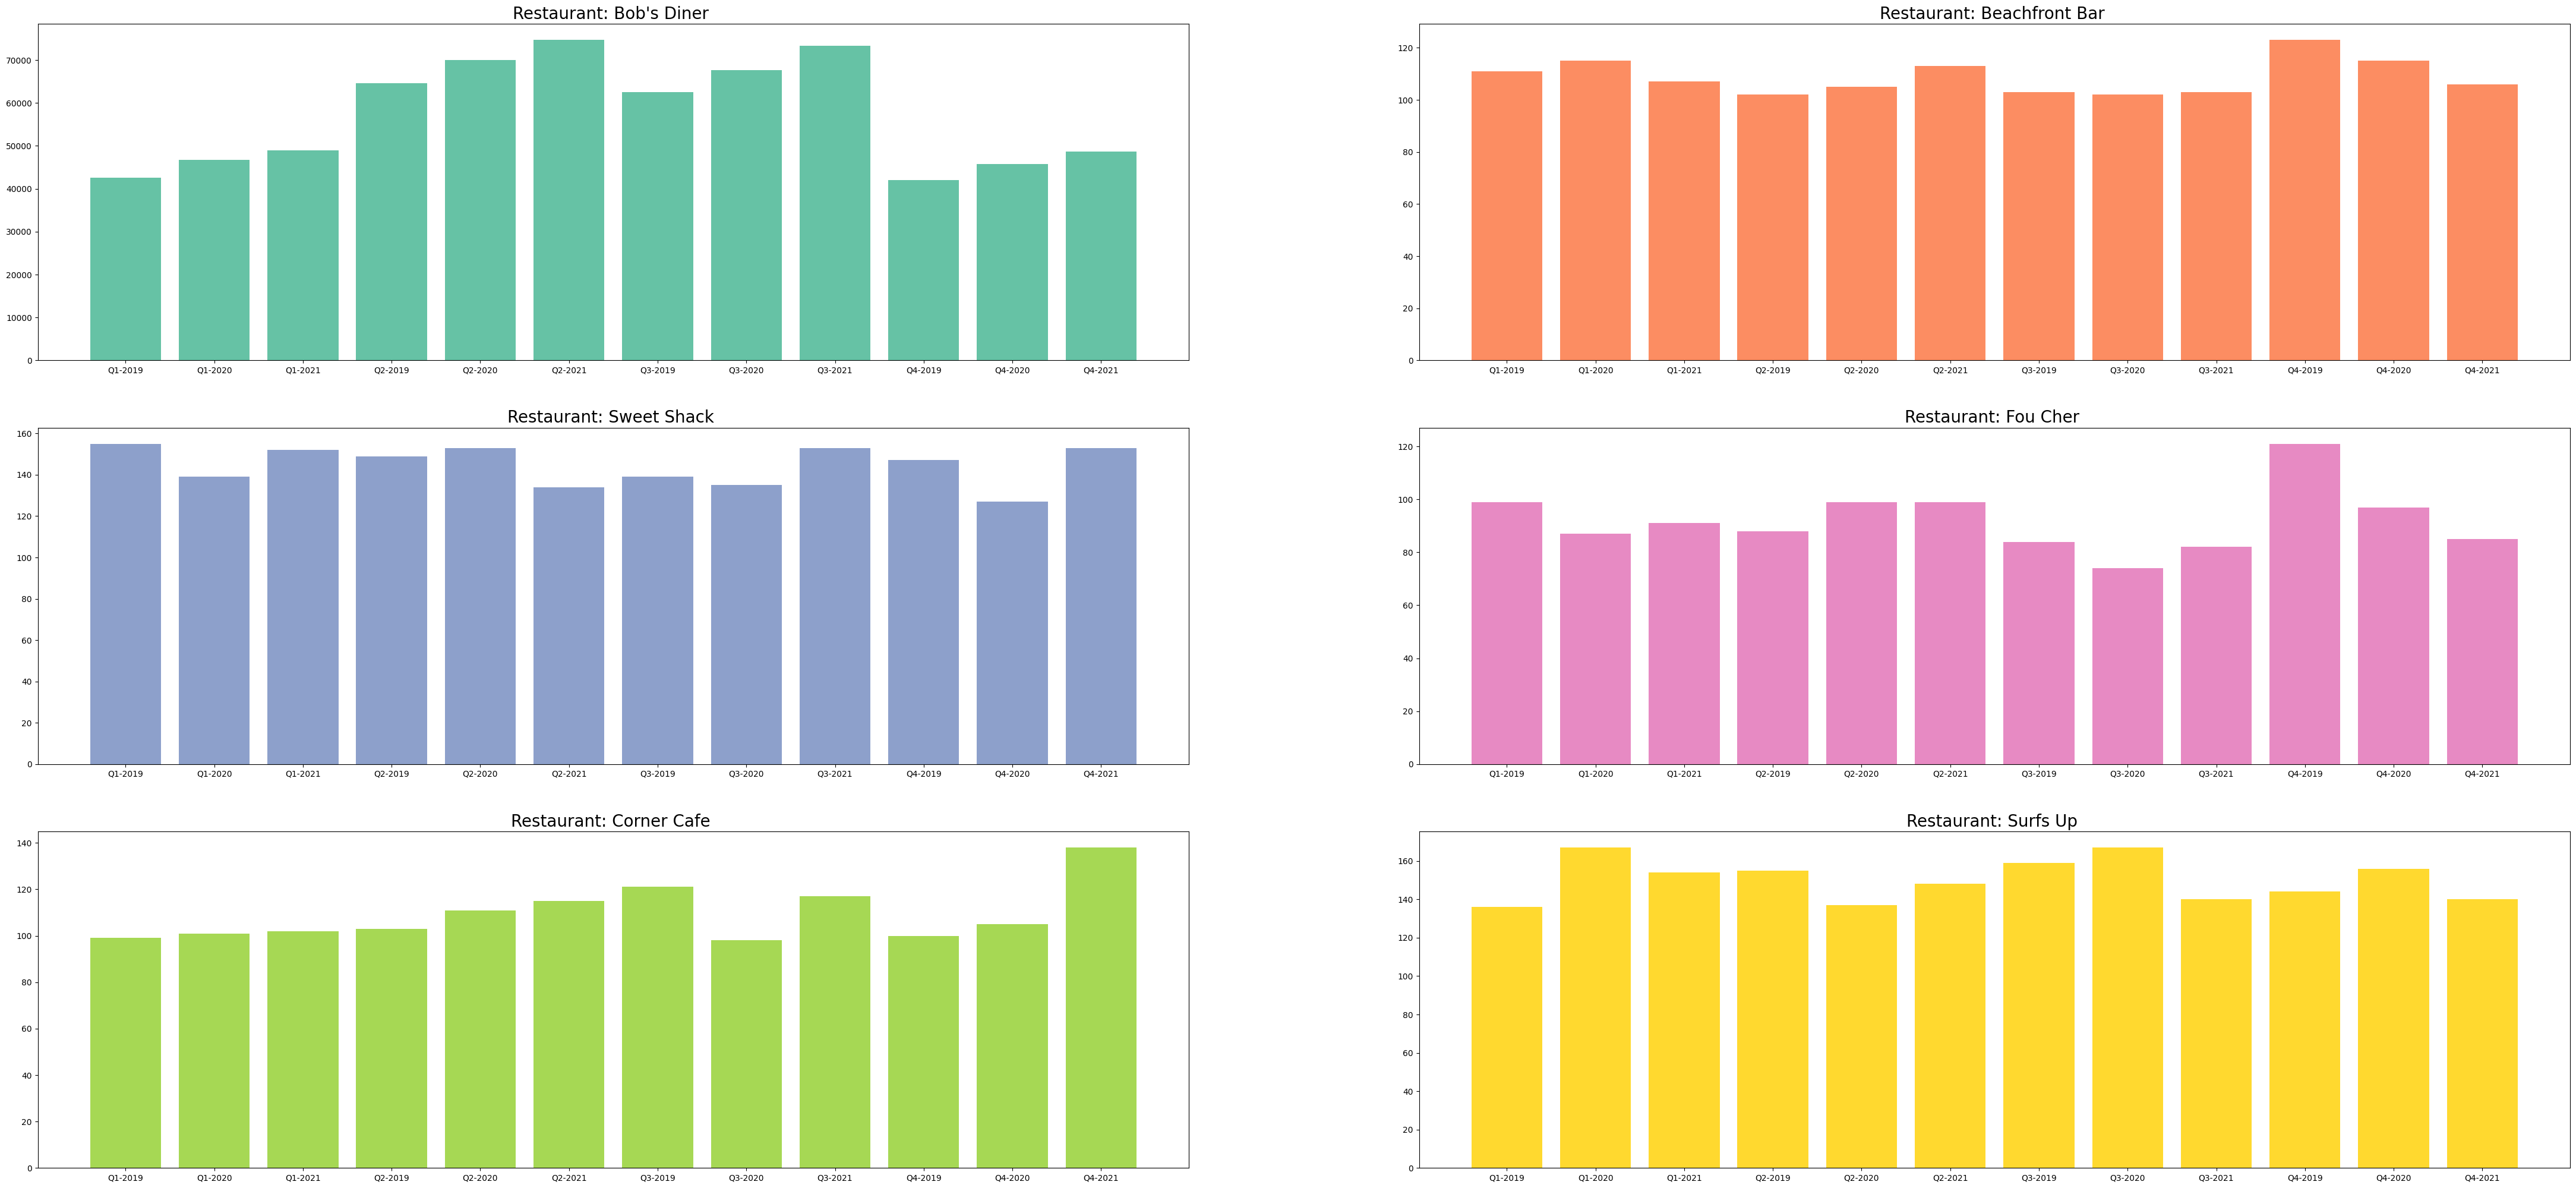

In [152]:
#Quarterly/yearly sales for each store

data['quarter'] = data.date.dt.quarter
data['year'] = data.date.dt.year
data['quart-year'] = "Q" + data.quarter.astype(str) + "-" + data.year.astype(str)

plot_data = data.pivot_table(index = 'quart-year', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data = data.pivot_table(index = 'quart-year', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
f,ax = plt.subplots(3,2,figsize =(55,25))
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('Restaurant: {} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

In [ ]:
### Bob's Diner has most sales in Q2 and Q3 each year.
### For the others, there's not much predictability or seasonality as such.

C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\2151446174.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\2151446174.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\2151446174.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\2151446174.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(

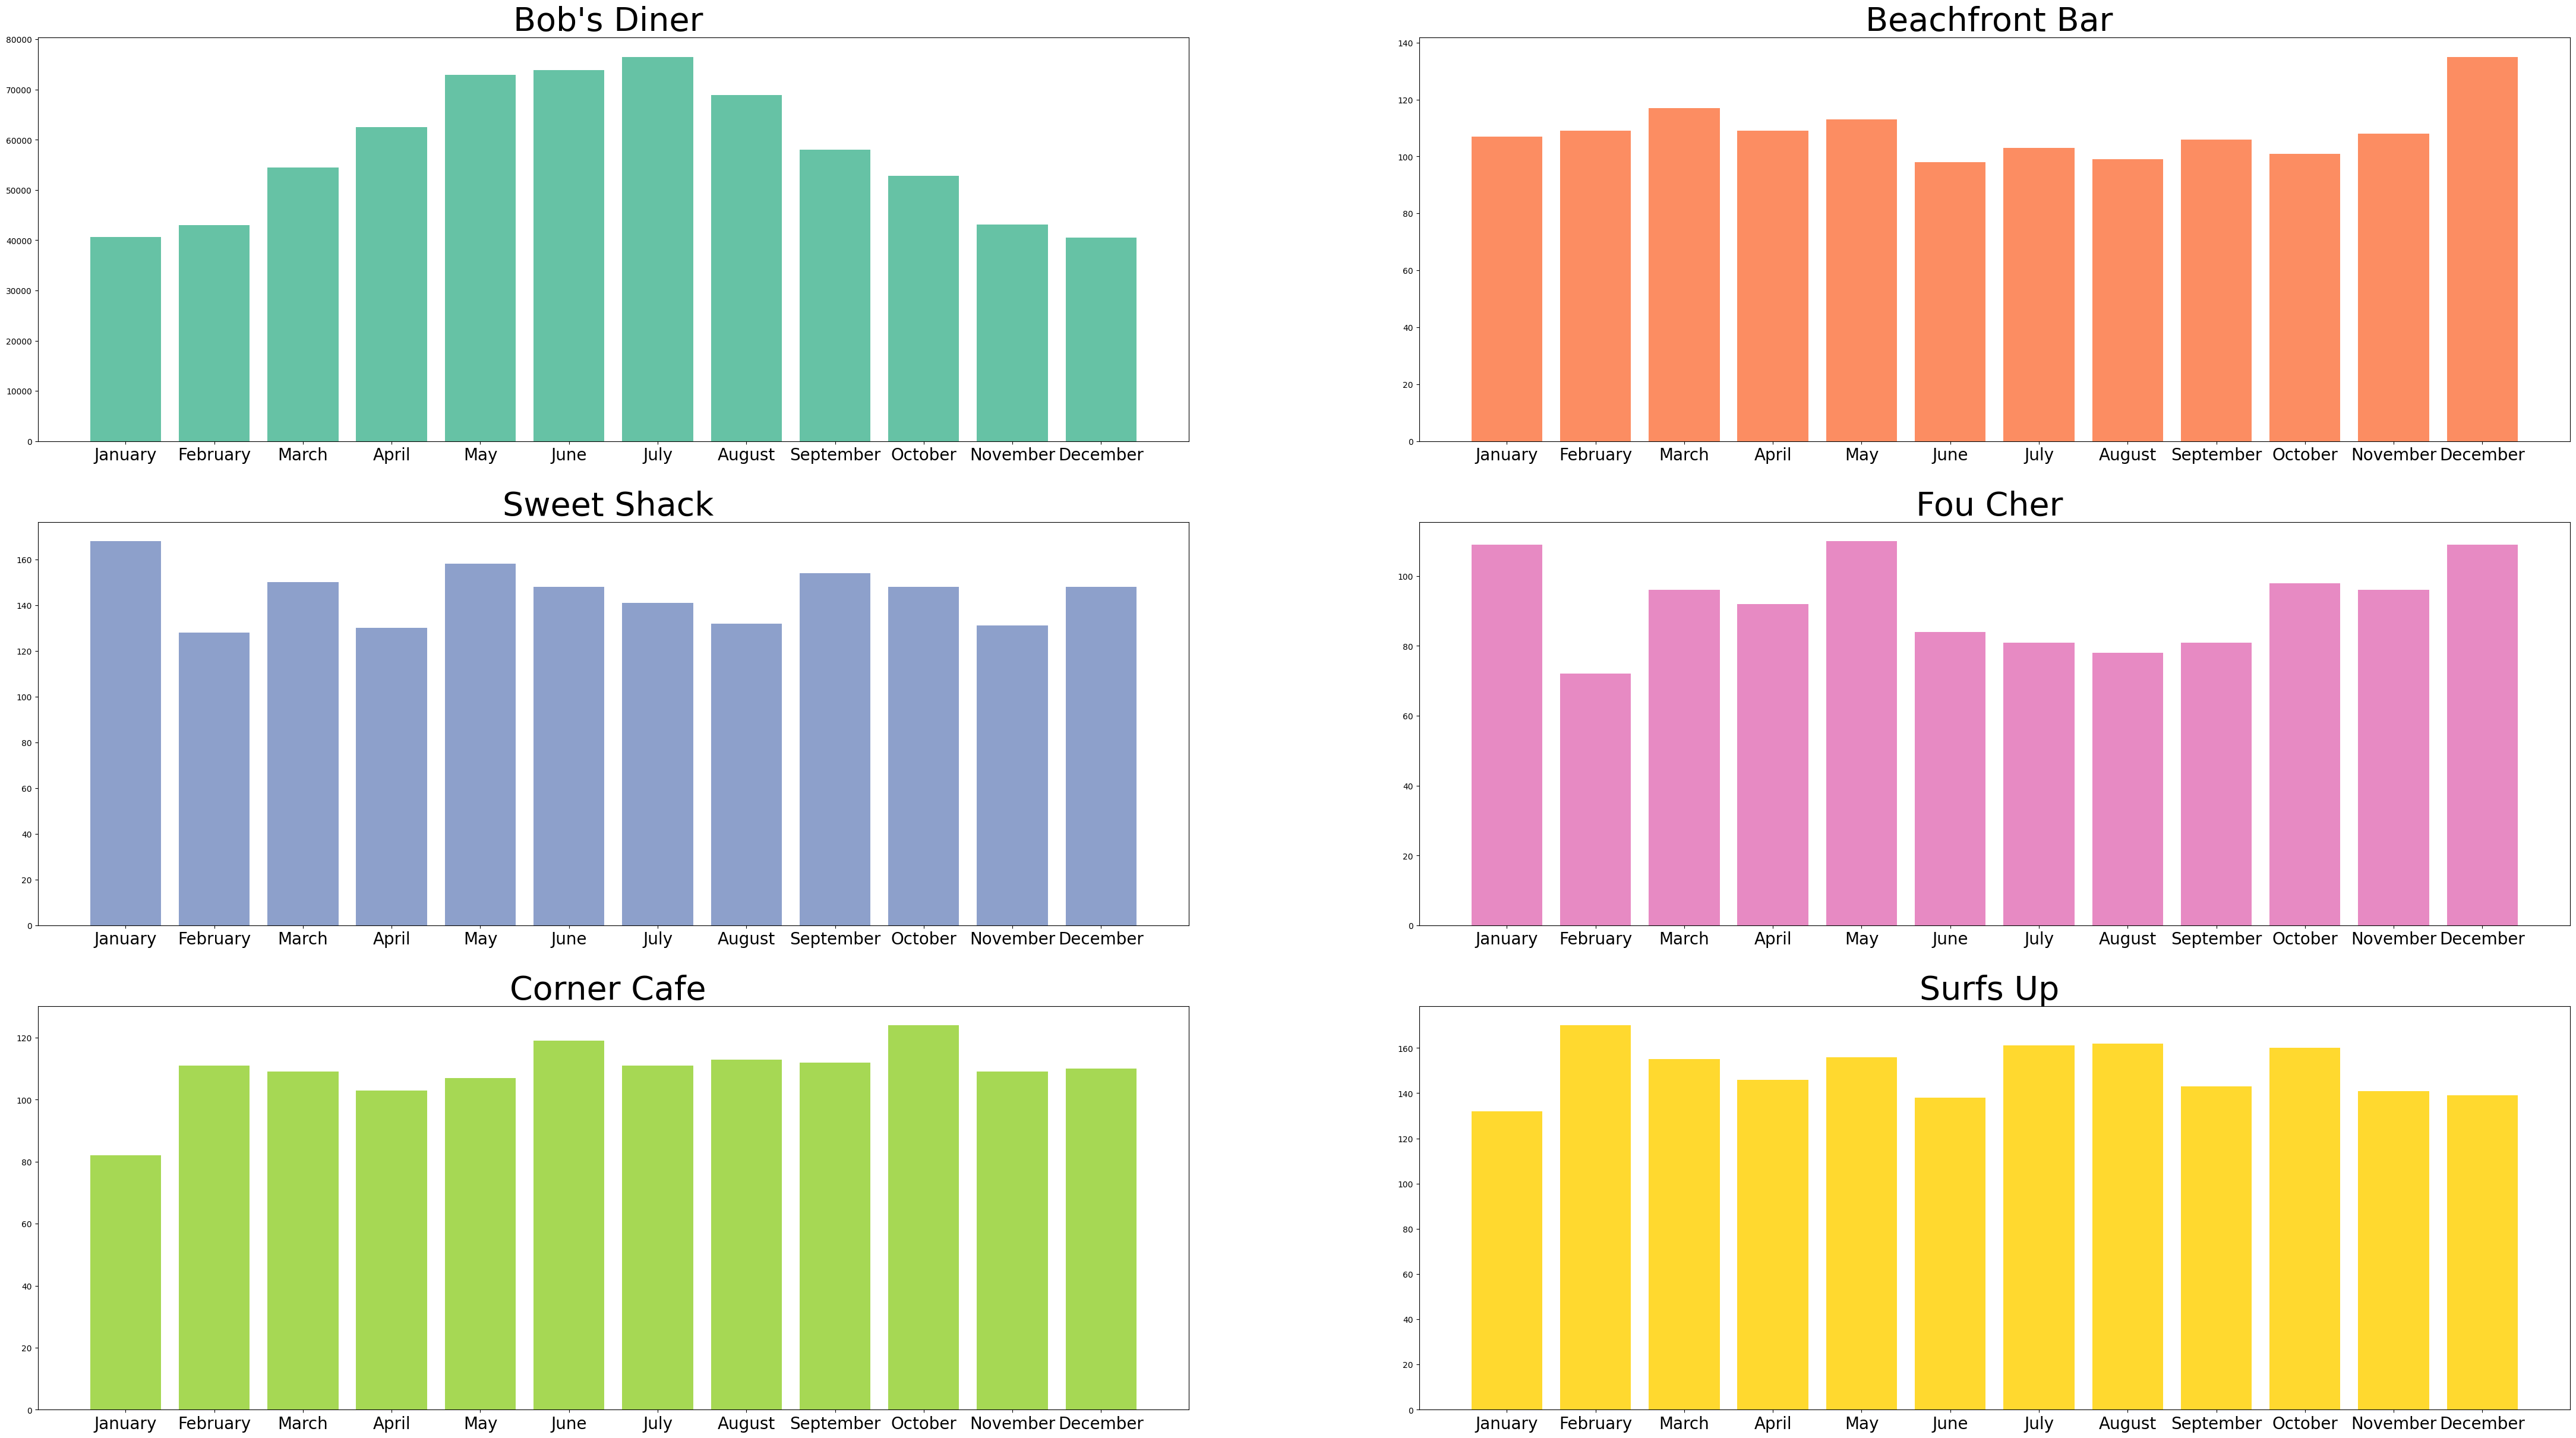

In [154]:
#Month wise sales
data['month_name'] = data.date.dt.month_name()
months = list(calendar.month_name)[1:]
plot_data = data.pivot_table(index = 'month_name', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data = plot_data.loc[months]
f,ax = plt.subplots(3,2,figsize =(55,30) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('{} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 40)
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

In [155]:
### As seen from quarters, Bob's Diner has most sales in July, with a spike around May-August.
### Fou Cher starts the years well but fades away.
### Beachfront Bar has most sales in December.
### Not a great deal of predictability for the other restaurants, though there are some seasonal spikes.

C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\1104656075.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\1104656075.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\1104656075.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
C:\Users\Saptarshi\AppData\Local\Temp\ipykernel_15060\1104656075.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xti

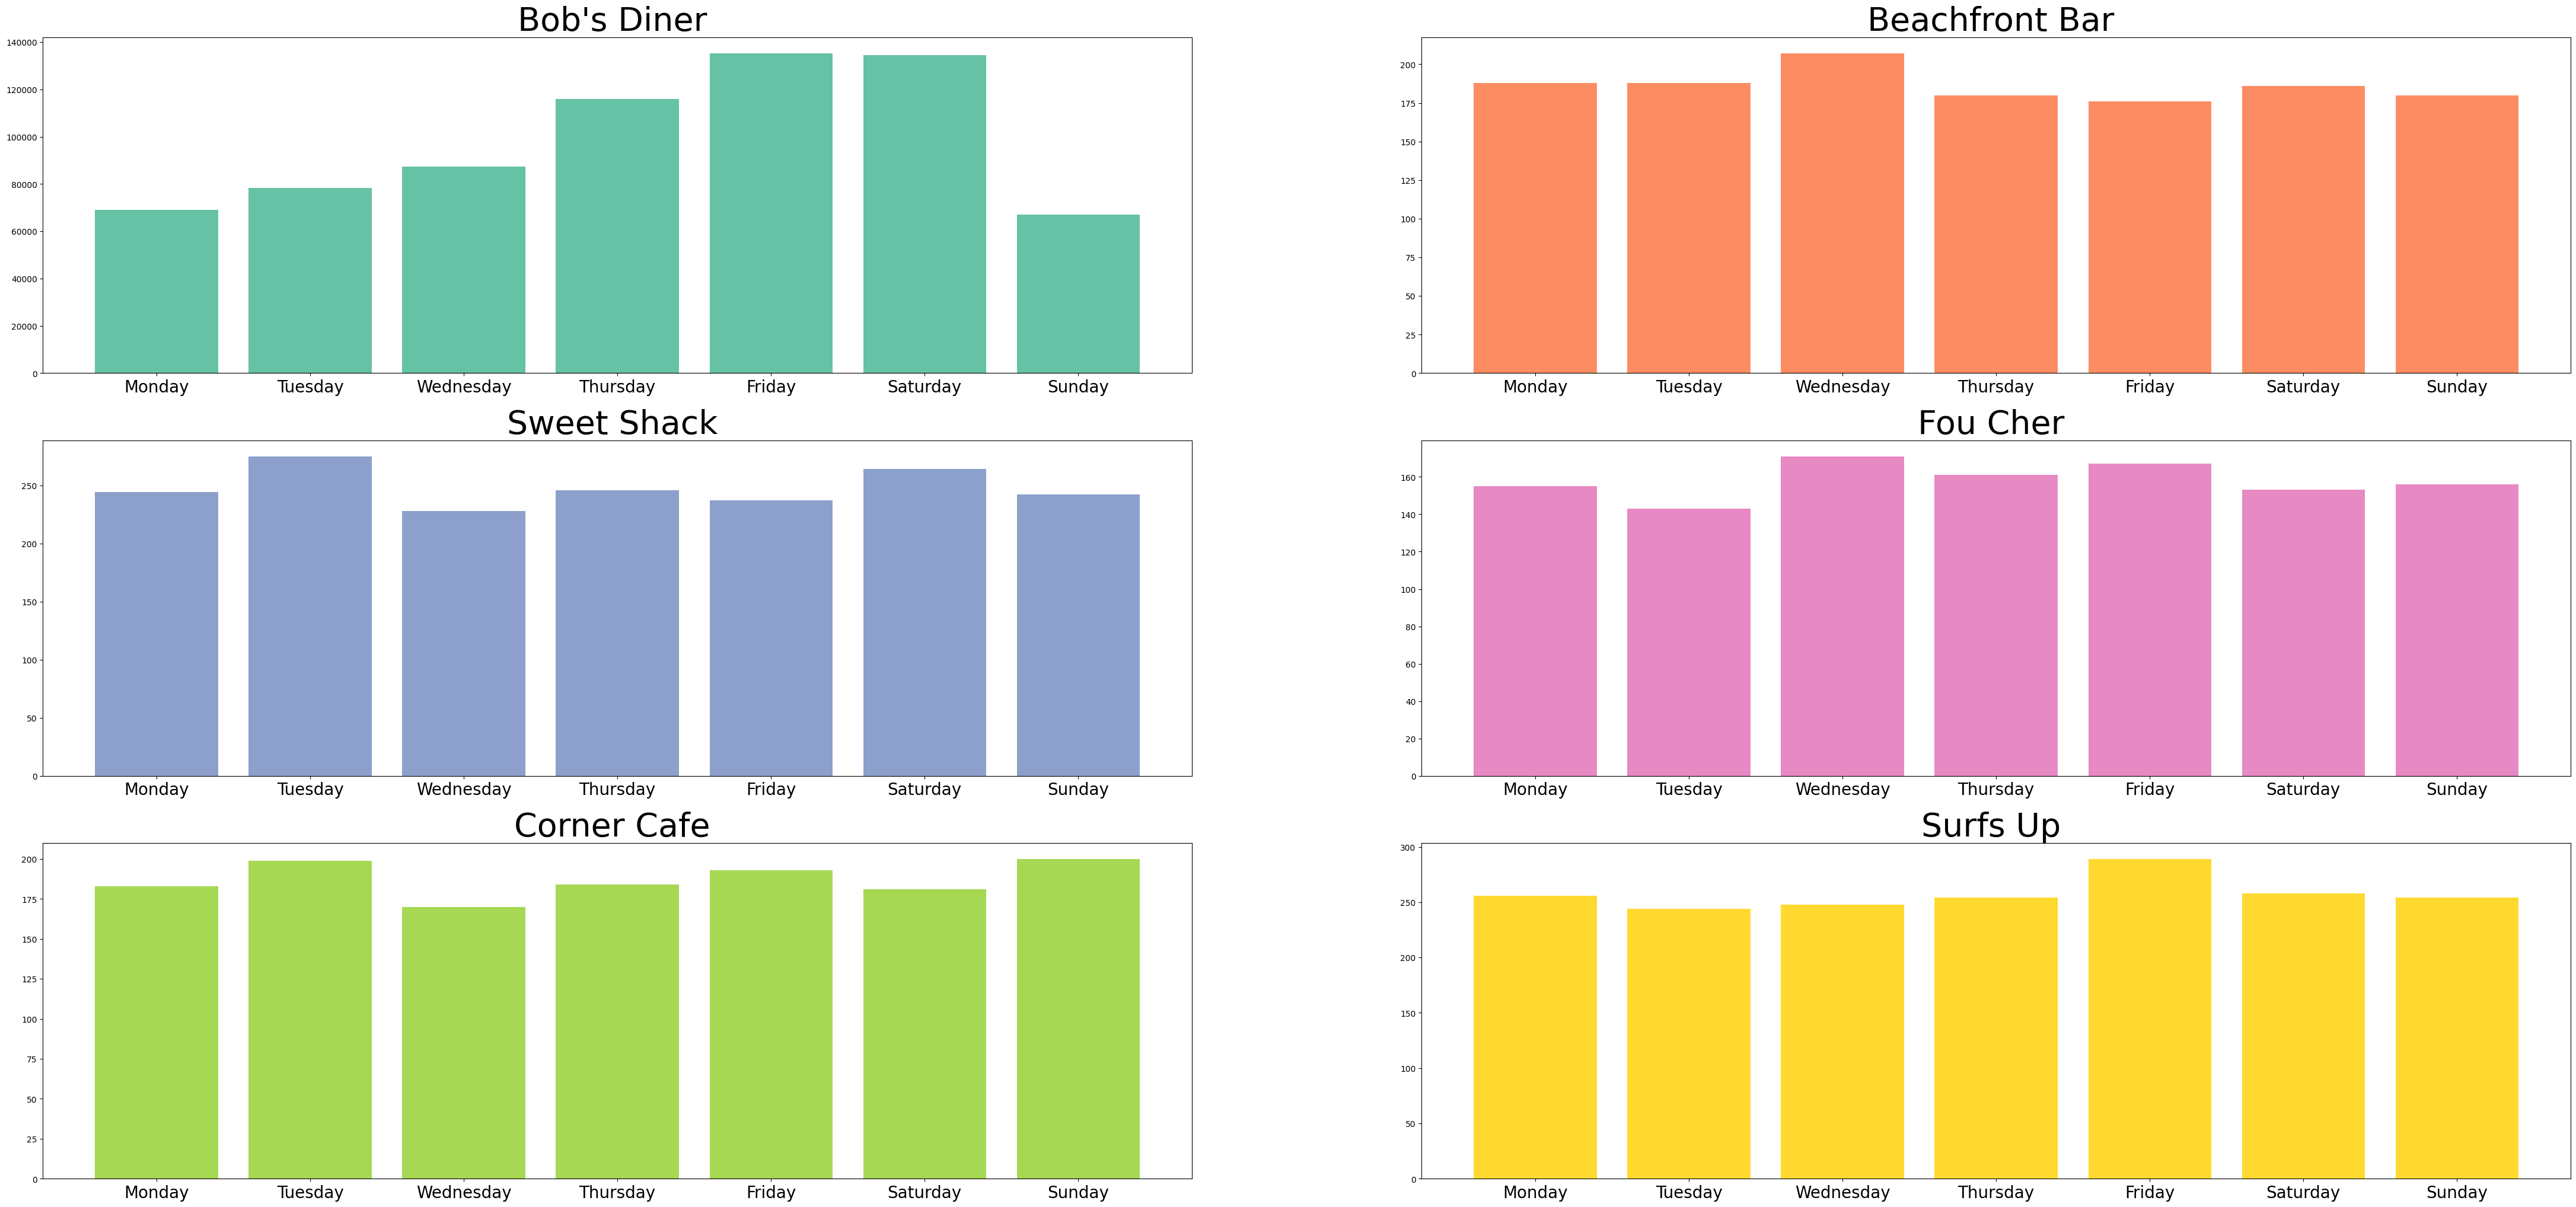

In [156]:
#Day wise sales
data['weekday'] = data.date.dt.day_name()
day_names = list(calendar.day_name)
plot_data = data.pivot_table(index = 'weekday', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data = plot_data.loc[day_names]
f,ax = plt.subplots(3,2,figsize =(55,25))
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('{} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 40)
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1
plt.show()

In [157]:
### Bob's Diner has most sales on Fridays and Saturdays, followed by Thursdays.
### Not a great deal of predictability for the other restaurants, though there are some spikes on certain days.

In [158]:
# Identify the most popular items overall and the stores where they are being sold. Also, find out the most popular item at each store .
plot_data = data.groupby('item_id')[['item_count']].sum().sort_values('item_count',ascending = False).reset_index()[:5]
final_plot_data = pd.merge(plot_data, items, left_on = 'item_id', right_on = 'id', how = 'left')[['item_id', 'item_count', 'name', 'kcal', 'cost', 'store_id']]
final_plot_data.head()

,item_id,item_count,name,kcal,cost,store_id
0,19,236337.0,Strawberry Smoothy,145,2.89,1
1,16,102990.0,Frozen Milky Smoothy,284,3.21,1
2,76,61043.0,Amazing pork lunch,679,17.93,1
3,38,52772.0,Mutton Dinner,542,10.80,1
4,9,43874.0,Orange Juice,135,3.91,1


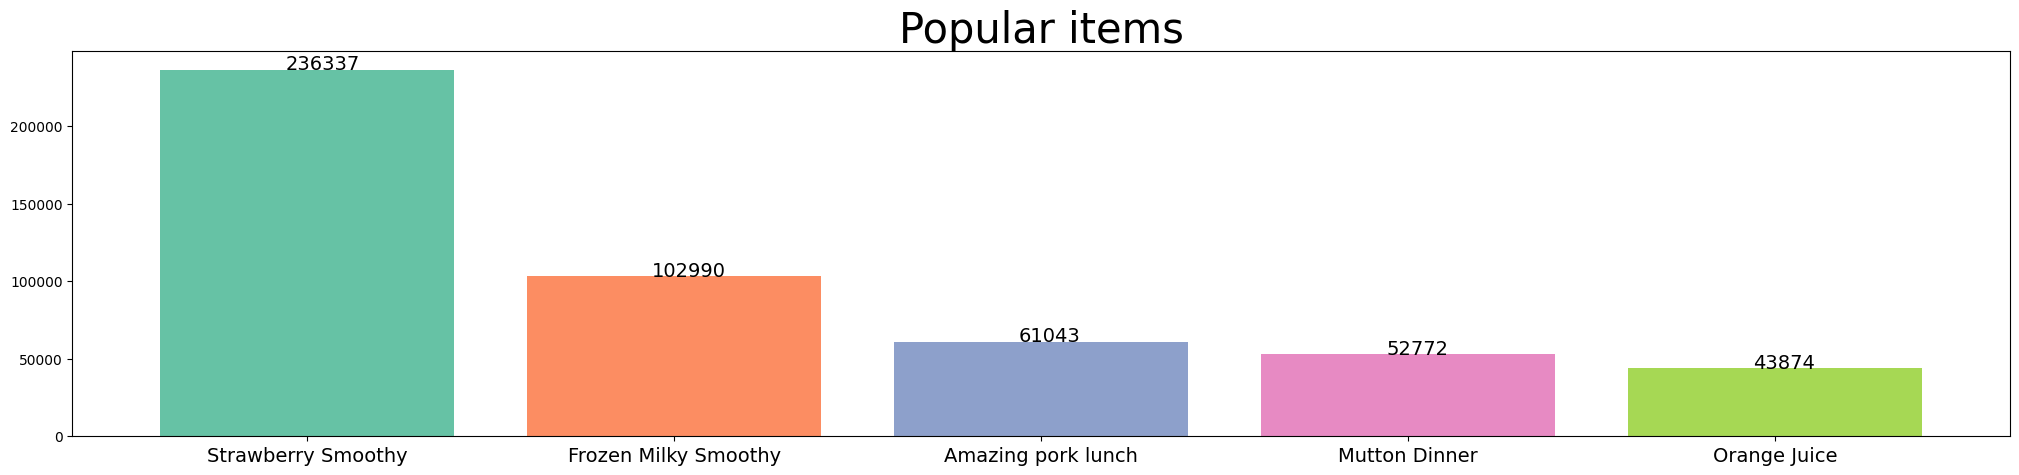

In [159]:
plt.figure(figsize = (25,5))
plt.bar(final_plot_data.name, final_plot_data.item_count, color = pal_list)
plt.title('Popular items', size= 30)
for k in range(5):
  val = final_plot_data.loc[k,'item_count']
  plt.annotate('{:0.0f}'.format(val), xy = (k-0.06, val), size = 14)
plt.xticks(size = 14)
plt.show()

In [160]:
### Strawberry Smoothy is by far the most sold item(2,36,337) while Orange juice is the least sold.

In [161]:
# Finding out the most popular item at each store
count_data = data.pivot_table(index = 'item_id', columns = 'store_id',values = 'item_count', aggfunc = 'sum', fill_value = 0 )
item_ids = count_data.index[count_data.values.argmax(axis = 0)]
item_ids

Index([19, 42, 49, 80, 71, 89], dtype='int64', name='item_id')

In [162]:
pop_items = items.loc[items.id.isin(item_ids), ['store_id', 'id', 'name', 'kcal', 'cost']]
pop_data = pd.merge(pop_items, restaurants, how = 'left', left_on = 'store_id', right_on = 'id', suffixes = ('_item', '_restaurant'))
pop_data['count'] = count_data.loc[item_ids,].sum(axis = 0).reset_index().iloc[:,1]
pop_data = pop_data[['name_restaurant', 'name_item', 'kcal', 'cost', 'count']]
pop_data

,name_restaurant,name_item,kcal,cost,count
0,Bob's Diner,Strawberry Smoothy,145,2.89,236337.0
1,Beachfront Bar,Fantastic Milky Smoothy,318,2.91,1147.0
2,Sweet Shack,Awesome Smoothy,78,1.39,1692.0
3,Corner Cafe,Frozen Milky Smoothy,211,3.98,298.0
4,Fou Cher,Blue Ribbon Fruity Vegi Lunch,881,53.98,273.0
5,Surfs Up,Awesome Soft Drink,248,3.06,997.0


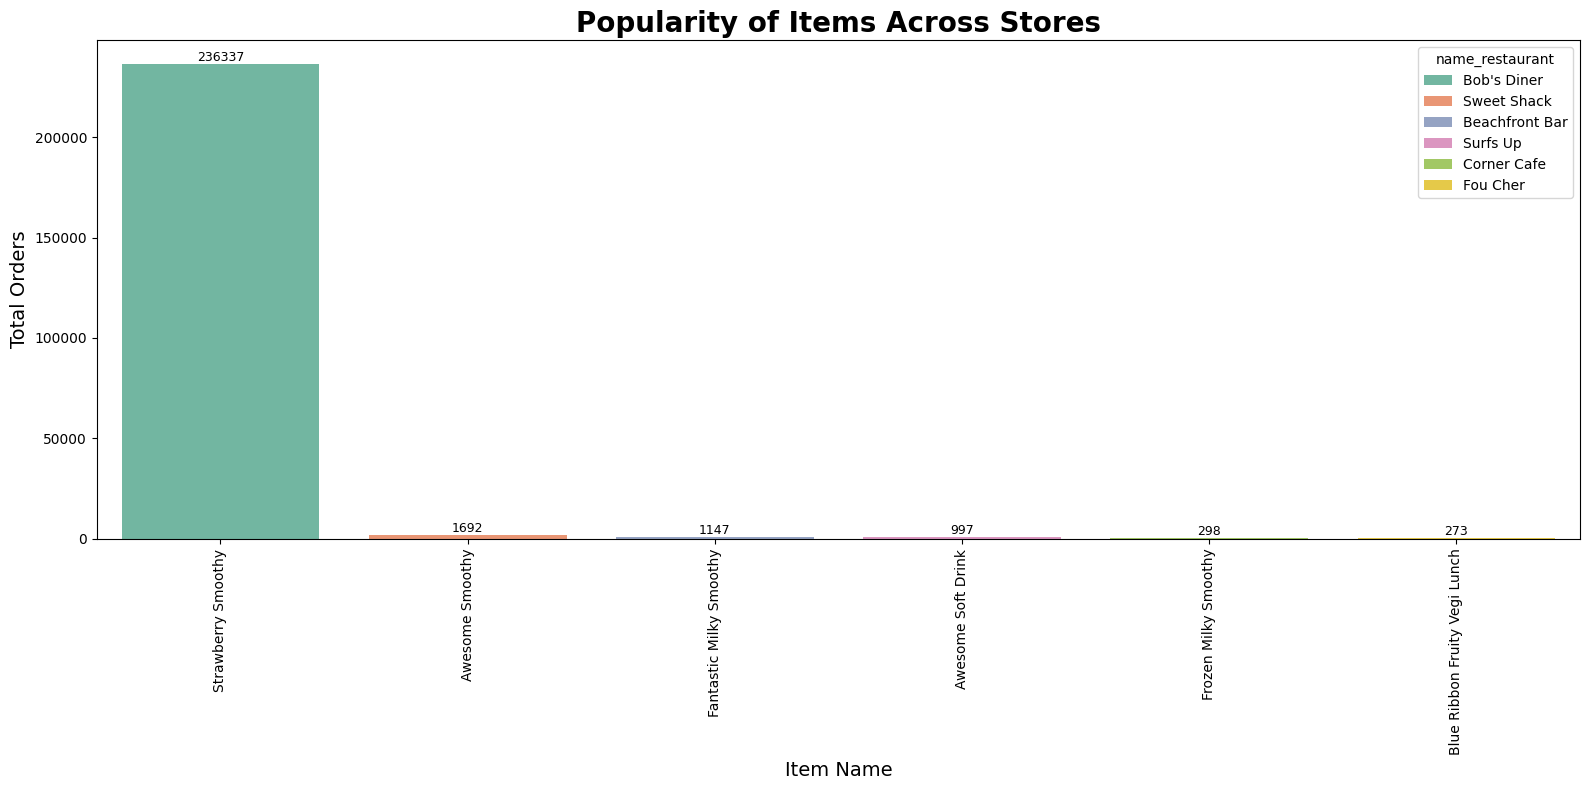

In [163]:
plot_df = pop_data.sort_values('count', ascending=False)

# Create figure
plt.figure(figsize=(16,8))

# Barplot
ax = sns.barplot(
    data=plot_df,
    x='name_item',
    y='count',
    hue='name_restaurant',
    palette='Set2'
)

# Rotate labels
plt.xticks(rotation=90)

# Titles
plt.title(
    'Popularity of Items Across Stores',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel('Item Name', fontsize=14)
plt.ylabel('Total Orders', fontsize=14)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()

In [164]:
### Bob's Diner leads the chart with Strawberry Smoothy being the most sold item.
### Next best is Awesome Smoothy in Sweet Shack, which is around 139 times lesser than Strawberry Smoothy in Bob's Diner.

In [165]:
# Determine if the store with the highest sales volume is also making the most money per day
data.groupby('store_id')[['item_count']].sum().reset_index()
data.pivot_table(index = 'store_id', columns = 'year', values = 'item_count', aggfunc = 'sum')

year,2019,2020,2021
store_id,,,
1,211799.0,230191.0,245537.0
2,439.0,437.0,429.0
3,590.0,554.0,592.0
4,392.0,357.0,357.0
5,423.0,415.0,472.0
6,594.0,627.0,582.0


In [166]:
data['sales_amnt'] = data.item_count * data.price
data.pivot_table(index = 'store_id', columns = 'year', values = 'sales_amnt', aggfunc = 'sum').round(2)


year,2019,2020,2021
store_id,,,
1,1849483.49,2112331.91,2375460.29
2,1281.85,1267.21,1247.14
3,872.59,828.65,877.03
4,9698.80,8590.87,9595.70
5,5292.93,5347.71,5910.79
6,5132.65,5314.43,5204.41


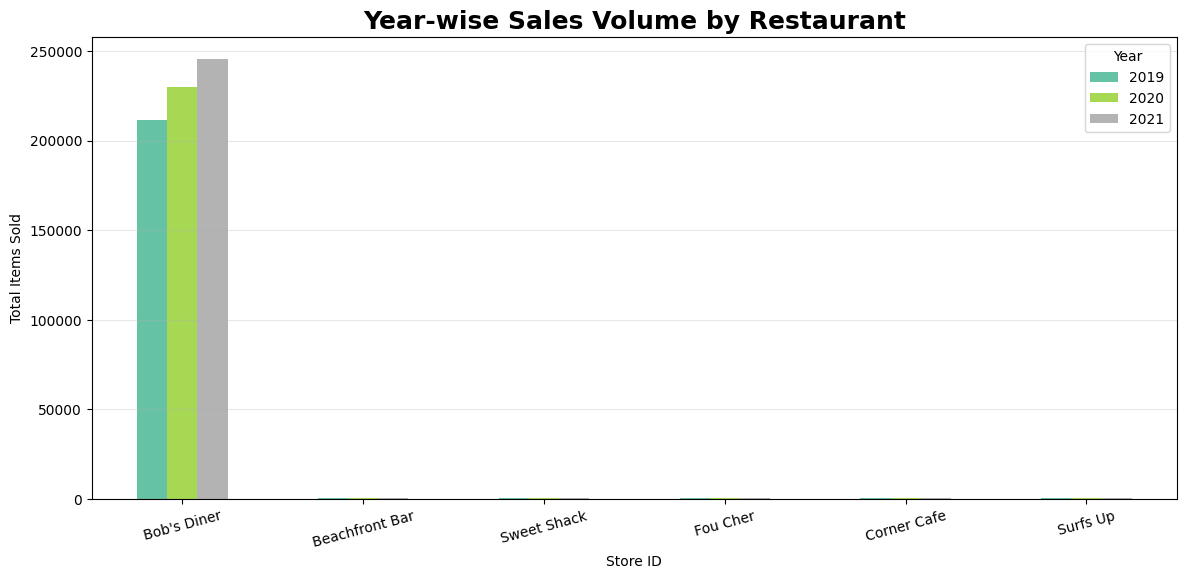

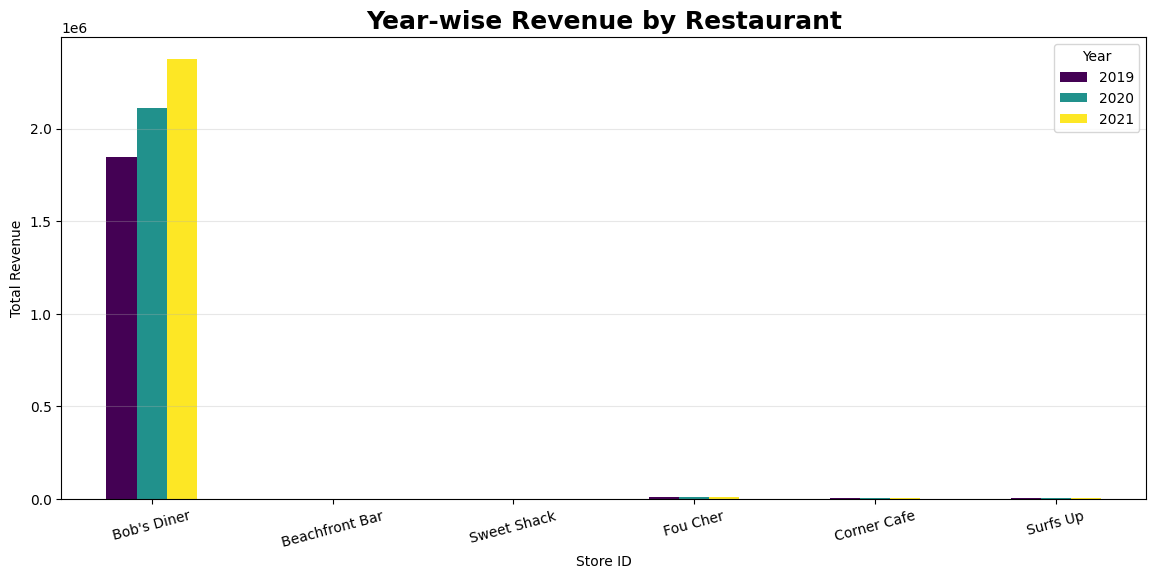

In [167]:
# -------------------------------
# SALES VOLUME PLOT
# -------------------------------

# Pivot table for sales volume
volume_pivot = data.pivot_table(
    index='store_id',
    columns='year',
    values='item_count',
    aggfunc='sum'
)

# Plot
volume_pivot.plot(
    kind='bar',
    figsize=(14,6),
    colormap='Set2'
)

plt.title(
    'Year-wise Sales Volume by Restaurant',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Store ID')
plt.ylabel('Total Items Sold')

plt.xticks(
    ticks=range(len(volume_pivot.index)),
    labels=restaurants['name'],
    rotation=15
)

plt.legend(title='Year')
plt.grid(axis='y', alpha=0.3)

plt.show()



# -------------------------------
# SALES REVENUE PLOT
# -------------------------------

# Create revenue column
data['sales_amnt'] = data.item_count * data.price

# Pivot table for revenue
revenue_pivot = data.pivot_table(
    index='store_id',
    columns='year',
    values='sales_amnt',
    aggfunc='sum'
).round(2)

# Plot
revenue_pivot.plot(
    kind='bar',
    figsize=(14,6),
    colormap='viridis'
)

plt.title(
    'Year-wise Revenue by Restaurant',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Store ID')
plt.ylabel('Total Revenue')

plt.xticks(
    ticks=range(len(revenue_pivot.index)),
    labels=restaurants['name'],
    rotation=15
)

plt.legend(title='Year')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [168]:
### Again we see, Bob's Diner has the highest sales volume as well as revenue, followed by Beachfront Bar.Most revenue is correlated with most volume of sales.

In [169]:
# Identify the most expensive item at each restaurant and find out its calorie count
items_rest = pd.merge(items, restaurants, left_on = 'store_id', right_on = 'id', how = 'left', suffixes = ('_item', '_restaurant'))
items_rest.head()

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
0,1,4,Chocolate Cake,554,6.71,4,Fou Cher
1,2,4,Breaded Fish with Vegetables Meal,772,15.09,4,Fou Cher
2,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
3,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
4,5,5,Milk Cake,583,6.07,5,Corner Cafe


In [170]:
items_rest.sort_values("cost",ascending = False)[:5]

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
79,80,4,Blue Ribbon Fruity Vegi Lunch,881,53.98,4,Fou Cher
2,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
55,56,1,Sea Bass with Vegetables Dinner,613,28.75,1,Bob's Diner
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,4,Fou Cher
33,34,4,Sweet Savory Cake,721,27.47,4,Fou Cher


In [171]:
### Overall the most expensive items are:
# 1.  Blue Ribbon Fruity Vegi Lunch in Fou Cher
# 2.  Sweet Fruity Cake in Bob's Diner
# 3.  Sea Basee with Vegetables Dinner in Bob's Diner

In [172]:
items_rest[items_rest['store_id'] == 1].sort_values('cost', ascending = False)[:5]

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
2,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
55,56,1,Sea Bass with Vegetables Dinner,613,28.75,1,Bob's Diner
3,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
44,45,1,Awesome Fish with Vegetables Entree,227,23.43,1,Bob's Diner
58,59,1,Blue Ribbon Beef Entree,392,23.37,1,Bob's Diner


In [173]:
items_rest[items_rest['store_id'] == 2].sort_values('cost', ascending = False)[:5]

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
61,62,2,Sweet Vegi Soft Drink,538,5.70,2,Beachfront Bar
97,98,2,Original Sweet Milky Soft Drink,579,5.00,2,Beachfront Bar
77,78,2,Original Gin Cocktail,279,2.99,2,Beachfront Bar
41,42,2,Fantastic Milky Smoothy,318,2.91,2,Beachfront Bar
99,100,2,Awesome Vodka Cocktail,223,2.48,2,Beachfront Bar


In [174]:
items_rest[items_rest['store_id'] == 3].sort_values('cost', ascending = False)[:5]

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
76,77,3,Blue Ribbon Frozen Milky Cake,636,7.70,3,Sweet Shack
45,46,3,Blue Ribbon Milky Cake,612,6.89,3,Sweet Shack
85,86,3,Original Milky Cake,595,6.50,3,Sweet Shack
51,52,3,Original Sweet Milky Soft Drink,535,5.68,3,Sweet Shack
80,81,3,Fantastic Milky Smoothy,383,5.11,3,Sweet Shack


In [175]:
items_rest[items_rest['store_id'] == 4].sort_values('cost', ascending = False)[:5]

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
79,80,4,Blue Ribbon Fruity Vegi Lunch,881,53.98,4,Fou Cher
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,4,Fou Cher
33,34,4,Sweet Savory Cake,721,27.47,4,Fou Cher
39,40,4,Fantastic Fruity Salmon with Bread meal,815,22.67,4,Fou Cher
64,65,4,Lamb with Bread and Vegetables Meal,724,20.02,4,Fou Cher


In [176]:
items_rest[items_rest['store_id'] == 5].sort_values('cost', ascending = False)[:5]

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
49,50,5,Pike Lunch,653,26.37,5,Corner Cafe
68,69,5,Awesome Hamburger with Fries,673,26.04,5,Corner Cafe
95,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93,5,Corner Cafe
35,36,5,Fantastic Fish with Vegetables Entree,232,21.14,5,Corner Cafe
9,10,5,Mutton with Roles and Vegetables Plate,820,21.13,5,Corner Cafe


In [177]:
items_rest[items_rest['store_id'] == 6].sort_values('cost', ascending = False)[:5]

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
26,27,6,Steak Meal,607,26.21,6,Surfs Up
7,8,6,Amazing Trout with Vegetables Dinner,258,24.98,6,Surfs Up
32,33,6,Original Breaded Pork with Vegetables Dinner,1023,20.80,6,Surfs Up
60,61,6,Awesome Pork with Vegetables Lunch,848,18.53,6,Surfs Up
63,64,6,Roast Mutton Entree,293,16.09,6,Surfs Up


In [178]:
for i in range(1,7):
  print("Most expensive item in {} is {} with cost {} and calories {}".format(restaurants.loc[restaurants.id == i, 'name'].values[0], 
                                                                              items.loc[(items.store_id == i) & (items.cost == items[items.store_id == i].cost.max()), 'name'].values[0], items.loc[(items.store_id == i) & (items.cost == items[items.store_id == i].cost.max()), 'cost'].values[0], 
                                                                              items.loc[(items.store_id == i) & (items.cost == items[items.store_id == i].cost.max()), 'kcal'].values[0]))

Most expensive item in Bob's Diner is Sweet Fruity Cake with cost 29.22 and calories 931
Most expensive item in Beachfront Bar is Sweet Vegi Soft Drink with cost 5.7 and calories 538
Most expensive item in Sweet Shack is Blue Ribbon Frozen Milky Cake with cost 7.7 and calories 636
Most expensive item in Fou Cher is Blue Ribbon Fruity Vegi Lunch with cost 53.98 and calories 881
Most expensive item in Corner Cafe is Pike Lunch with cost 26.37 and calories 653
Most expensive item in Surfs Up is Steak Meal with cost 26.21 and calories 607


In [179]:
# Most expensive item in Bob's Diner is Sweet Fruity Cake with cost 29.22 and calories 931
# Most expensive item in Beachfront Bar is Sweet Vegi Soft Drink with cost 5.7 and calories 538
# Most expensive item in Sweet Shack is Blue Ribbon Frozen Milky Cake with cost 7.7 and calories 636
# Most expensive item in Fou Cher is Blue Ribbon Fruity Vegi Lunch with cost 53.98 and calories 881
# Most expensive item in Corner Cafe is Pike Lunch with cost 26.37 and calories 653
# Most expensive item in Surfs Up is Steak Meal with cost 26.21 and calories 607

### Forecasting using machine learning algorithms

In [180]:
time_series = data.groupby(['date']).agg({'item_count':'sum', 'weekday': lambda x :x.unique()[0],
                            'quarter' : lambda x :x.unique()[0], 'year': lambda x :x.unique()[0],
                            'month_name' : lambda x :x.unique()[0],
                            'year':lambda x :x.unique()[0]})
time_series.head()

,item_count,weekday,quarter,year,month_name
date,,,,,
2019-01-01,427.0,Tuesday,1,2019,January
2019-01-02,337.0,Wednesday,1,2019,January
2019-01-03,445.0,Thursday,1,2019,January
2019-01-04,564.0,Friday,1,2019,January
2019-01-05,552.0,Saturday,1,2019,January


In [181]:
time_series['day_year'] = time_series.index.day_of_year
time_series['day_month'] = time_series.index.day
time_series['week_num'] = time_series.index.isocalendar().week.astype(int)
time_series.head()

,item_count,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2019-01-01,427.0,Tuesday,1,2019,January,1,1,1
2019-01-02,337.0,Wednesday,1,2019,January,2,2,1
2019-01-03,445.0,Thursday,1,2019,January,3,3,1
2019-01-04,564.0,Friday,1,2019,January,4,4,1
2019-01-05,552.0,Saturday,1,2019,January,5,5,1


In [182]:
from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder(categories = [months, day_names])
ord_enc.fit(time_series[['month_name', 'weekday']])
time_series[['month_name', 'weekday']] = ord_enc.transform(time_series[['month_name', 'weekday']])
time_series.head()

,item_count,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2019-01-01,427.0,1.0,1,2019,0.0,1,1,1
2019-01-02,337.0,2.0,1,2019,0.0,2,2,1
2019-01-03,445.0,3.0,1,2019,0.0,3,3,1
2019-01-04,564.0,4.0,1,2019,0.0,4,4,1
2019-01-05,552.0,5.0,1,2019,0.0,5,5,1


In [183]:
# Train-test split
train = time_series[time_series.index < '2021-07-01']
test = time_series[time_series.index >= '2021-07-01']

In [184]:
y_var = 'item_count'
x_vars = time_series.drop(columns = 'item_count').columns

X_train = train[x_vars]
Y_train = train[y_var]
X_test = test[x_vars]
Y_test = test[y_var]

In [185]:

lr = LinearRegression()
lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [186]:
test['lr_pred'] = lr.predict(X_test)

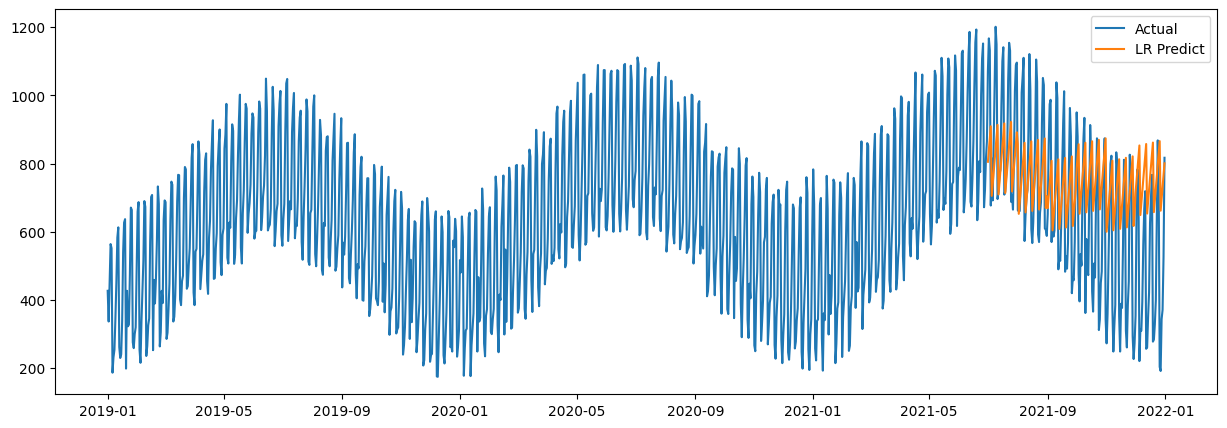

In [187]:
plt.figure(figsize = (15,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.lr_pred, label = "LR Predict")
plt.legend()
plt.show()

In [188]:
lr_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.lr_pred)
lr_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.lr_pred)
lr_r2_score = r2_score(y_true = test.item_count, y_pred = test.lr_pred)
print("Linear Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(lr_rmse,lr_mae,lr_r2_score*100))

Linear Regression :
RMSE : 59638.94
MAE : 196.04
R2_Score : 7.65


In [189]:
rf = RandomForestRegressor(n_estimators=100, max_depth=20)
rf.fit(X_train, Y_train)
test['rf_pred'] = rf.predict(X_test)

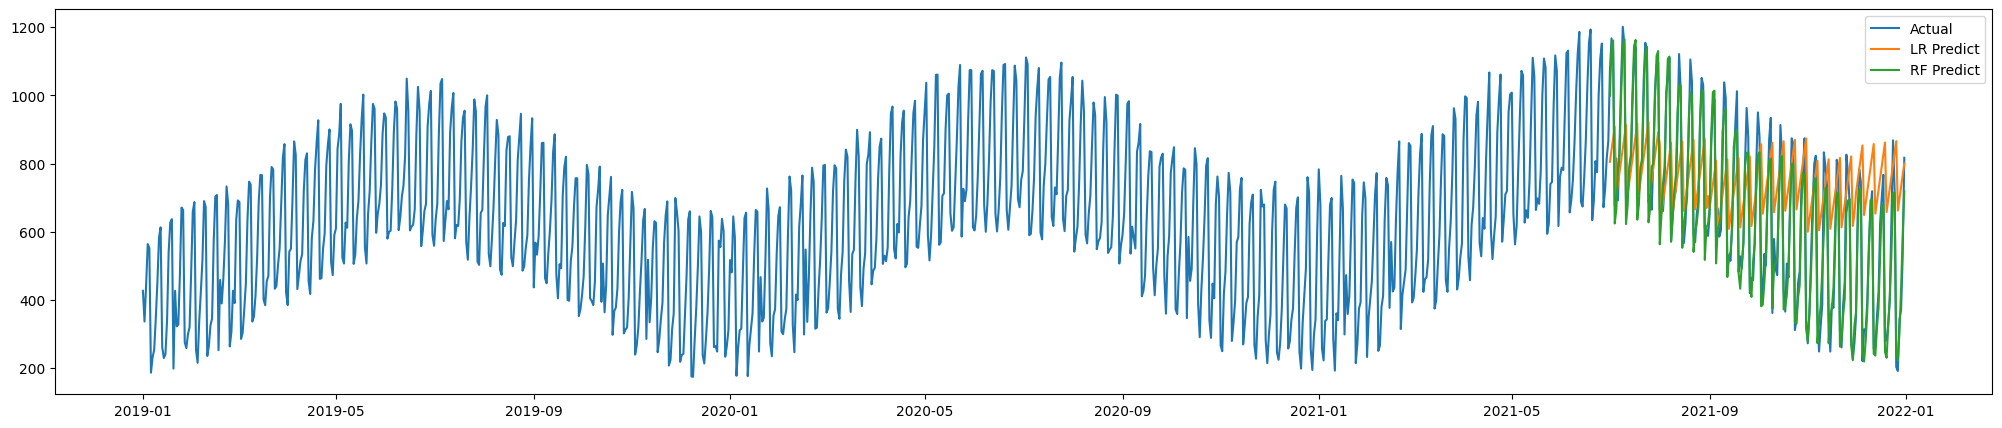

In [190]:
plt.figure(figsize = (25,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.lr_pred, label = "LR Predict")
plt.plot(test.rf_pred, label = "RF Predict")
plt.legend()
plt.show()

In [191]:
rf_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.rf_pred)
rf_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.rf_pred)
rf_r2_score = r2_score(y_true = test.item_count, y_pred = test.rf_pred)
print("Random Forest Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(rf_rmse,rf_mae,rf_r2_score*100))

Random Forest Regression :
RMSE : 3566.09
MAE : 47.27
R2_Score : 94.48


In [192]:
xgb = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
xgb.fit(X_train, Y_train,
        eval_set=[(X_train, Y_train), (X_test, Y_test)],
        verbose=100)
test['xgb_pred'] = xgb.predict(X_test)

[0]	validation_0-rmse:660.07829	validation_1-rmse:709.01212
[100]	validation_0-rmse:262.51190	validation_1-rmse:311.53220
[200]	validation_0-rmse:121.36888	validation_1-rmse:171.11193
[300]	validation_0-rmse:71.72975	validation_1-rmse:105.03640
[400]	validation_0-rmse:52.50055	validation_1-rmse:78.37923

c:\Users\Saptarshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\callback.py:386: UserWarning: [21:10:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[500]	validation_0-rmse:44.19461	validation_1-rmse:71.59216
[591]	validation_0-rmse:40.35475	validation_1-rmse:72.11224


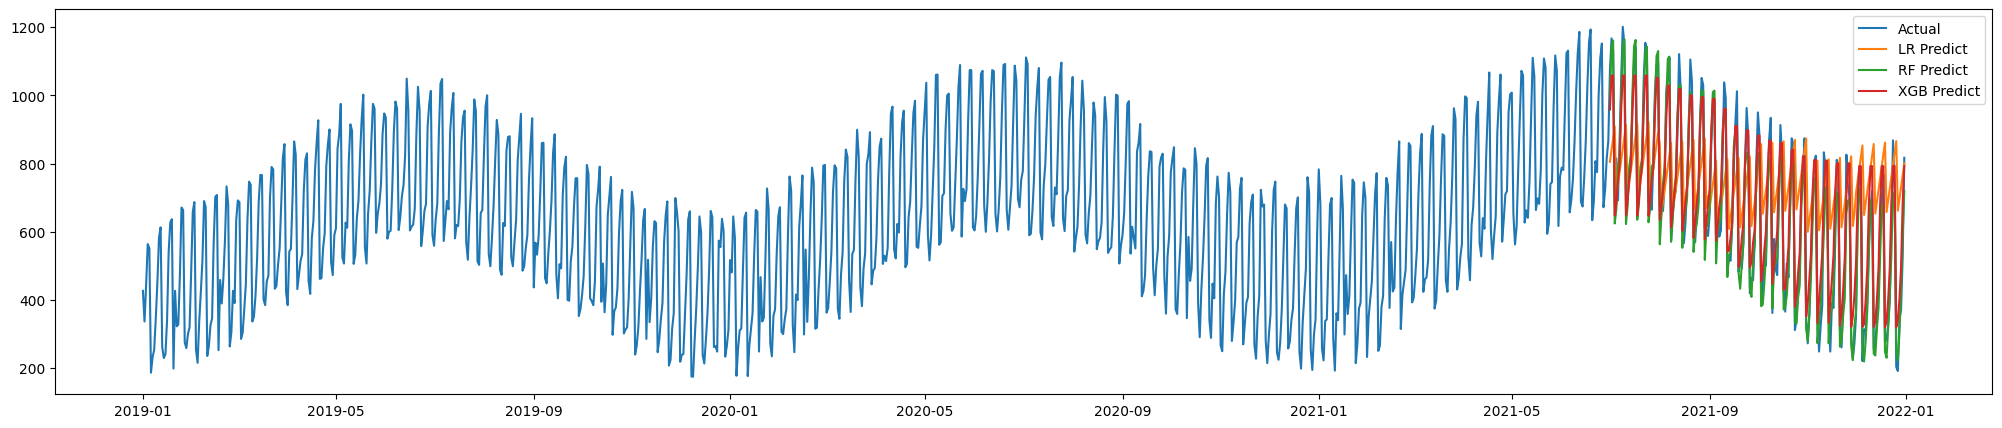

In [193]:
plt.figure(figsize = (25,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.lr_pred, label = "LR Predict")
plt.plot(test.rf_pred, label = "RF Predict")
plt.plot(test.xgb_pred, label = "XGB Predict")
plt.legend()
plt.show()

In [194]:
xgb_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.xgb_pred)
xgb_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.xgb_pred)
xgb_r2_score = r2_score(y_true = test.item_count, y_pred = test.xgb_pred)
print("XGBoost :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(xgb_rmse,xgb_mae,xgb_r2_score*100))

XGBoost :
RMSE : 5066.29
MAE : 58.45
R2_Score : 92.15


In [195]:
### Summary of all all 3 model scores:
print("Model Performance Comparison:\n")
print("Linear Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}%\n".format(lr_rmse,lr_mae,lr_r2_score*100))
print("Random Forest Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}%\n".format(rf_rmse,rf_mae,rf_r2_score*100))
print("XGBoost :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}%\n".format(xgb_rmse,xgb_mae,xgb_r2_score*100))

Model Performance Comparison:

Linear Regression :
RMSE : 59638.94
MAE : 196.04
R2_Score : 7.65%

Random Forest Regression :
RMSE : 3566.09
MAE : 47.27
R2_Score : 94.48%

XGBoost :
RMSE : 5066.29
MAE : 58.45
R2_Score : 92.15%



In [196]:
### Clearly Random Forest Regression gives the best output among all three models.
### Let's try parameter tuning for Random Forest Regression to see if we can get better results.

# -----------------------------
# Define Model
# -----------------------------

rf_model = RandomForestRegressor(
    random_state=42
)

# -----------------------------
# Hyperparameter Grid
# -----------------------------

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# -----------------------------
# Grid Search
# -----------------------------

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

# -----------------------------
# Train
# -----------------------------

grid_search.fit(X_train, Y_train)

# -----------------------------
# Best Parameters
# -----------------------------

print("Best Parameters:")
print(grid_search.best_params_)

# -----------------------------
# Best Model
# -----------------------------

best_rf = grid_search.best_estimator_

# -----------------------------
# Predictions
# -----------------------------

rf_pred = best_rf.predict(X_test)

# -----------------------------
# Evaluation Metrics
# -----------------------------

rf_rmse = np.sqrt(
    mean_squared_error(y_true=Y_test, y_pred=rf_pred)
)

rf_mae = mean_absolute_error(
    y_true=Y_test,
    y_pred=rf_pred
)

rf_r2_score = r2_score(
    y_true=Y_test,
    y_pred=rf_pred
)

# -----------------------------
# Print Results
# -----------------------------

print("\nTuned Random Forest Regression:")

print("RMSE : {:.2f}".format(rf_rmse))
print("MAE : {:.2f}".format(rf_mae))
print("R2 Score : {:.2f}%".format(rf_r2_score * 100))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Tuned Random Forest Regression:
RMSE : 86.47
MAE : 68.92
R2 Score : 88.42%


In [197]:
### So we have been able to improve the RF regressor with hyperparameter tuning.
### Now tiem to do some forecasting with the best RF model.

In [198]:
### Forecasting future sales trend

In [199]:
time_series.index.max()

Timestamp('2021-12-31 00:00:00')

In [200]:

# Create future date dataframe
future_predictors = pd.DataFrame(
    pd.date_range(
        start="2022-01-01",
        end="2022-12-31"
    ),
    columns=['date']
)

# Set index
future_predictors.index = pd.to_datetime(
    future_predictors.date
)

# -----------------------------------------
# FEATURE ENGINEERING
# -----------------------------------------
future_predictors['weekday'] = future_predictors.date.dt.day_name()
future_predictors['quarter'] = future_predictors.date.dt.quarter
future_predictors['year'] = future_predictors.date.dt.year
future_predictors['month_name'] = future_predictors.date.dt.month_name()
future_predictors['day_year'] = future_predictors.date.dt.day_of_year
future_predictors['day_month'] = future_predictors.date.dt.day
future_predictors['week_num'] = future_predictors.date.dt.isocalendar().week

# -----------------------------------------
# ENCODING CATEGORICAL VARIABLES
# -----------------------------------------

future_predictors[['month_name', 'weekday']] = (
    ord_enc.transform(
        future_predictors[['month_name', 'weekday']]
    )
)
future_predictors.head()


,date,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2022-01-01,2022-01-01,5.0,1,2022,0.0,1,1,52
2022-01-02,2022-01-02,6.0,1,2022,0.0,2,2,52
2022-01-03,2022-01-03,0.0,1,2022,0.0,3,3,1
2022-01-04,2022-01-04,1.0,1,2022,0.0,4,4,1
2022-01-05,2022-01-05,2.0,1,2022,0.0,5,5,1


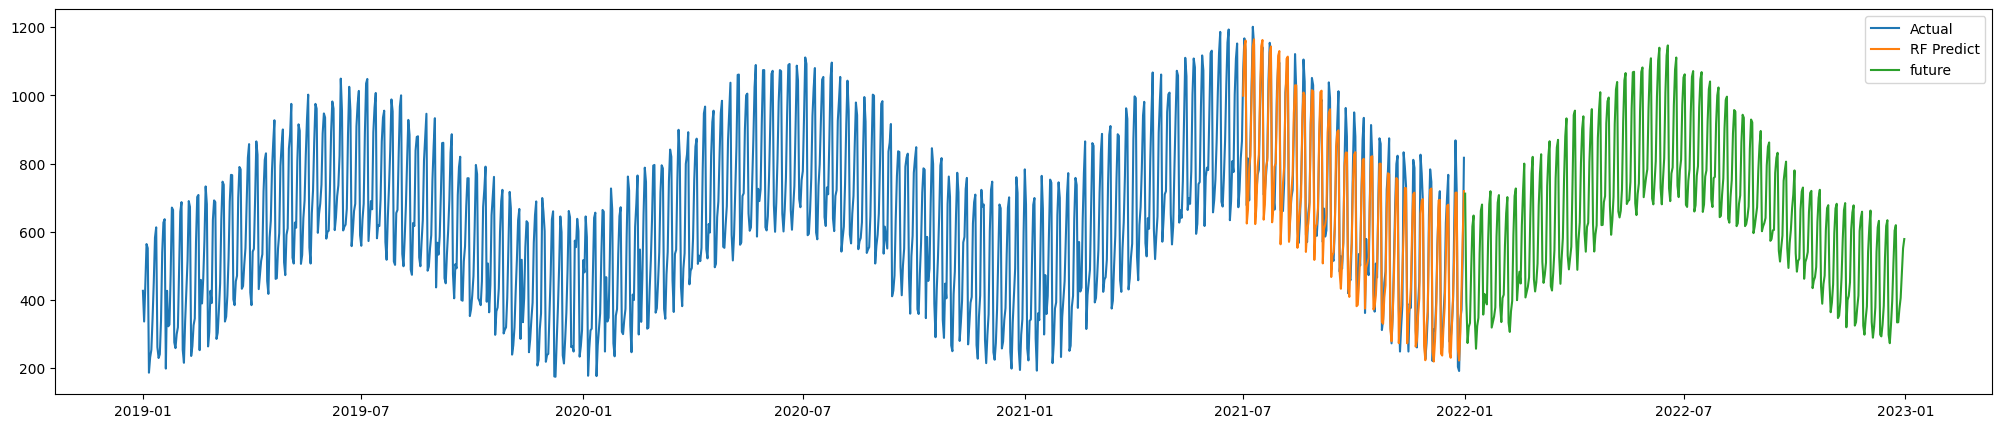

In [201]:

# -----------------------------------------
# FUTURE PREDICTIONS
# -----------------------------------------

future_predictors['predictions'] = best_rf.predict(future_predictors[X_train.columns])

plt.figure(figsize = (25,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.rf_pred, label = "RF Predict")
plt.plot(future_predictors.predictions, label = "future")
plt.legend()
plt.show()

In [202]:
### So our future prediction using our best RF regressor shows similar trends in 2022 as in 2021.
### Sales going to peak again around July - August (Q2) and then taper off towards the end of the year.
### However peak sales is a bit lower than 2021.